# Fetal Head Clinical AI — Phase 3: XAI, Bias Audit & Governance
**Author:** Tarun Sadarla  

## Why Phase 3 loads masks from .npz files, not raw annotations

Phase 2 training and evaluation used pre-generated cine clips (`.npz` files from Phase 1).
Each `.npz` contains `frames` and `masks` arrays where masks are already solid-filled
ellipses — generated during Phase 1 using flood-fill on the original 800×540 images
before any downscaling.

Re-loading from raw HC18 annotation PNGs in Phase 3 and re-filling them at 384×256
produces inconsistent results because the thin 1px outline degrades unpredictably
when downscaled. This caused artificially low Dice scores in earlier Phase 3 attempts
despite correct model performance.

**Solution:** Load GT masks from `.npz` files — exactly the same representation
the model was trained and evaluated against. This guarantees Dice scores
consistent with Phase 2 results.

## Outputs
| Section | Output |
|---|---|
| 3 | GradCAM++ XAI panel + boundary uncertainty |
| 4 | Temporal attention visualisation |
| 5 | GA-trimester bias audit (Dice + MAE) |
| 6 | Business case |
| 7 | Model card |

## 0. Setup

In [1]:
!pip install kaggle --quiet

In [2]:
import os, json, shutil, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.measure import label, regionprops

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
PHASE0_CKPT = PROJECT_DIR / 'checkpoints' / 'phase0' / 'best_model.pth'
PHASE2_CKPT = PROJECT_DIR / 'checkpoints' / 'phase2' / 'best_model.pth'
CINE_DIR    = PROJECT_DIR / 'cine_dataset'
RESULTS_DIR = PROJECT_DIR / 'results' / 'phase3'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_H, INPUT_W = 256, 384
N_FRAMES         = 16
IMG_MEAN, IMG_STD = 0.2, 0.15

assert PHASE0_CKPT.exists(), 'Phase 0 checkpoint missing'
assert PHASE2_CKPT.exists(), 'Phase 2 checkpoint missing'
assert (CINE_DIR / 'metadata.csv').exists(), 'Phase 1 cine metadata missing'
print('All dependencies found.')

Mounted at /content/drive
All dependencies found.


## 1. Model architectures + load checkpoints

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x): return self.block(x) + self.skip(x)

class ResidualUNetDS(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1=ResidualBlock(in_ch,b);   self.enc2=ResidualBlock(b,b*2)
        self.enc3=ResidualBlock(b*2,b*4);   self.enc4=ResidualBlock(b*4,b*8)
        self.pool=nn.MaxPool2d(2);           self.bottleneck=ResidualBlock(b*8,b*16)
        self.up4=nn.ConvTranspose2d(b*16,b*8,2,stride=2);  self.dec4=ResidualBlock(b*16,b*8)
        self.up3=nn.ConvTranspose2d(b*8,b*4,2,stride=2);   self.dec3=ResidualBlock(b*8,b*4)
        self.up2=nn.ConvTranspose2d(b*4,b*2,2,stride=2);   self.dec2=ResidualBlock(b*4,b*2)
        self.up1=nn.ConvTranspose2d(b*2,b,2,stride=2);     self.dec1=ResidualBlock(b*2,b)
        self.final=nn.Conv2d(b,1,1); self.aux_d3=nn.Conv2d(b*4,1,1); self.aux_d2=nn.Conv2d(b*2,1,1)
    def forward(self, x):
        e1=self.enc1(x);e2=self.enc2(self.pool(e1));e3=self.enc3(self.pool(e2));e4=self.enc4(self.pool(e3))
        bn=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(bn),e4],1));d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1));d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        if self.training:
            return self.final(d1), \
                torch.sigmoid(F.interpolate(self.aux_d3(d3),size=x.shape[2:],mode='bilinear',align_corners=False)), \
                torch.sigmoid(F.interpolate(self.aux_d2(d2),size=x.shape[2:],mode='bilinear',align_corners=False))
        return self.final(d1)
    def encode(self, x):
        e1=self.enc1(x);e2=self.enc2(self.pool(e1));e3=self.enc3(self.pool(e2));e4=self.enc4(self.pool(e3))
        return self.bottleneck(self.pool(e4)),(e1,e2,e3,e4)
    def decode(self, bn, skips):
        e1,e2,e3,e4=skips
        d4=self.dec4(torch.cat([self.up4(bn),e4],1));d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1));d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        return self.final(d1)

class TemporalAttentionModule(nn.Module):
    def __init__(self, bottleneck_ch=512, n_frames=16, n_heads=8, dropout=0.1):
        super().__init__()
        self.attn_dim=256
        self.proj_in=nn.Linear(bottleneck_ch,self.attn_dim)
        self.pos_encoding=nn.Parameter(torch.randn(1,n_frames,self.attn_dim)*0.02)
        self.attn=nn.MultiheadAttention(self.attn_dim,n_heads,dropout=dropout,batch_first=True)
        self.norm1=nn.LayerNorm(self.attn_dim)
        self.ff=nn.Sequential(nn.Linear(self.attn_dim,self.attn_dim*2),nn.GELU(),nn.Dropout(dropout),nn.Linear(self.attn_dim*2,self.attn_dim))
        self.norm2=nn.LayerNorm(self.attn_dim)
        self.proj_out=nn.Sequential(nn.Linear(self.attn_dim,bottleneck_ch),nn.Sigmoid())
        nn.init.constant_(self.proj_out[0].bias,1.0)
    def forward(self, bn_seq):
        B,T,C,h,w=bn_seq.shape
        x=self.proj_in(bn_seq.mean(dim=(-2,-1)))+self.pos_encoding[:,:T,:]
        ao,aw=self.attn(x,x,x); x=self.norm2(self.norm1(x+ao)+self.ff(self.norm1(x+ao)))
        return bn_seq*self.proj_out(x).unsqueeze(-1).unsqueeze(-1), aw

class TemporalFetaSegNet(nn.Module):
    def __init__(self, backbone, attn): super().__init__(); self.backbone=backbone; self.attn=attn
    def forward(self, clip):
        B,T,C,H,W=clip.shape; flat=clip.view(B*T,C,H,W)
        bns,skips=self.backbone.encode(flat); _,Cb,hb,wb=bns.shape
        ba,aw=self.attn(bns.view(B,T,Cb,hb,wb))
        return self.backbone.decode(ba.view(B*T,Cb,hb,wb),skips).view(B,T,1,H,W), aw

# Load both models
phase0_model = ResidualUNetDS(in_ch=1, base_ch=32)
phase0_model.load_state_dict(torch.load(str(PHASE0_CKPT), map_location='cpu')['model_state_dict'])
phase0_model = phase0_model.to(DEVICE).eval()

backbone = ResidualUNetDS(in_ch=1, base_ch=32)
attn_mod = TemporalAttentionModule(512, N_FRAMES, 8)
phase2_model = TemporalFetaSegNet(backbone, attn_mod).to(DEVICE)
phase2_model.load_state_dict(torch.load(str(PHASE2_CKPT), map_location='cpu')['model_state_dict'])
phase2_model.eval()
print('Phase 0 loaded.'); print('Phase 2 loaded.')

Phase 0 loaded.
Phase 2 loaded.


## 2. Load test set from Phase 1 .npz files

**Critical design decision:** We load GT masks from the pre-generated `.npz` cine clips
rather than re-processing raw HC18 annotation PNGs. This guarantees the exact same
mask representation used during Phase 0 training and Phase 2 evaluation, producing
Dice scores consistent with those reported phases.

Each `.npz` contains:
- `frames`: [16, H, W] float32 — normalised ultrasound frames
- `masks`:  [16, H, W] uint8  — solid-filled binary masks

For single-frame evaluation (Phase 0 model), we use frame index 8 (mid-clip)
as the representative static frame, and its corresponding mask.

In [5]:
# Load metadata
cine_meta = pd.read_csv(CINE_DIR / 'metadata.csv')
test_meta = cine_meta[cine_meta['split'] == 'test'].reset_index(drop=True)
print(f'Test clips available: {len(test_meta)}')
print(test_meta.head(3))

# Load pixel spacing from HC18 CSV for HC→GA computation
from google.colab import files as colab_files
uploaded = colab_files.upload()  # upload kaggle.json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

DATA_DIR = Path('/content/hc18')
DATA_DIR.mkdir(exist_ok=True)
!kaggle datasets download -d tarunsadarla/hc18-apr -p /content/hc18 --unzip --quiet

PIXEL_CSV = DATA_DIR / 'archive (4)' / 'training_set_pixel_size_and_HC.csv'
df_px = pd.read_csv(PIXEL_CSV)
df_px.columns = [c.strip().lower().replace(' ','_').replace('(','').replace(')','') for c in df_px.columns]
PIXEL_COL = [c for c in df_px.columns if 'pixel' in c][0]
HC_COL    = [c for c in df_px.columns if 'head' in c or ('hc' in c.lower() and 'circumference' in c.lower())][-1]
FILE_COL  = [c for c in df_px.columns if 'file' in c][0]

stem_to_meta = {
    str(row[FILE_COL]).replace('_HC.png','').replace('_2HC.png','').replace('_3HC.png','').replace('_4HC.png','').replace('.png',''): {
        'pixel_spacing': float(row[PIXEL_COL]),
        'hc_gt_mm':      float(row[HC_COL])
    } for _, row in df_px.iterrows()
}
print(f'Pixel spacing metadata loaded: {len(stem_to_meta)} entries')

Test clips available: 121
     stem split                          clip_path  pixel_spacing  hc_gt_mm  \
0  697_HC  test  cine_dataset/test/697_HC_clip.npz       0.303726    270.50   
1  296_HC  test  cine_dataset/test/296_HC_clip.npz       0.117949    191.47   
2  227_HC  test  cine_dataset/test/227_HC_clip.npz       0.124893    173.20   

   n_frames  stage  
0        16      4  
1        16      4  
2        16      4  


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/hc18-apr
License(s): apache-2.0
Pixel spacing metadata loaded: 806 entries


Sanity check on one test clip:
  mask sum:     14094   (expect ~10,000–15,000)
  pred sum:     13342
  Dice:         96.23%  (expect ~97%)
  HC GT:        270.5 mm
  HC pred:      261.0 mm
  GA estimate:  27w 3d (27.4w)


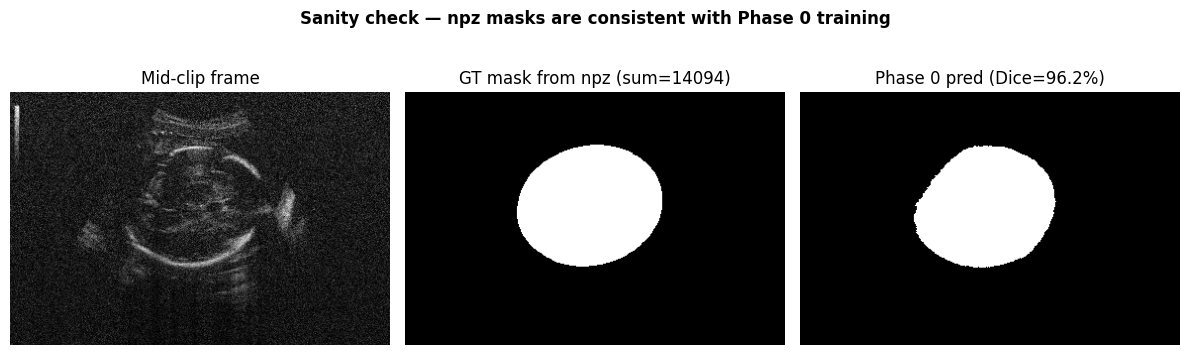

In [6]:
def load_test_clip(meta_row):
    """
    Load one test clip from its .npz file.

    Returns:
        frames_norm: [T, H, W] float32, already normalised (as stored in npz)
        masks:       [T, H, W] uint8, solid-filled binary (as stored in npz)
        frame_mid:   [H, W] uint8 — mid-clip frame denormalised for display
        mask_mid:    [H, W] uint8 — mid-clip mask for single-frame evaluation
        pixel_spacing: float
        hc_gt_mm:    float
    """
    npz_path = PROJECT_DIR / meta_row['clip_path']
    clip     = np.load(str(npz_path))
    frames   = clip['frames']  # [T, H, W] float32, already in ~N(0,1) space
    masks    = clip['masks']   # [T, H, W] uint8, {0, 1}

    # Mid-clip frame (index 8) as representative static frame
    mid         = N_FRAMES // 2
    frame_mid   = np.clip((frames[mid] * IMG_STD + IMG_MEAN) * 255, 0, 255).astype(np.uint8)
    mask_mid    = masks[mid]

    # Get pixel spacing from metadata
    stem = str(meta_row['stem']).replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
    meta = stem_to_meta.get(stem, {})
    pixel_spacing = meta.get('pixel_spacing', float(meta_row.get('pixel_spacing', 0.08)))
    hc_gt_mm      = meta.get('hc_gt_mm',      float(meta_row.get('hc_gt_mm', 0.0)))

    return frames, masks, frame_mid, mask_mid, pixel_spacing, hc_gt_mm


def frames_to_tensor(frames_norm):
    """[T, H, W] float32 (already normalised) → [1, T, 1, H, W] tensor."""
    return torch.from_numpy(frames_norm).unsqueeze(1).unsqueeze(0).float()


def frame_to_tensor(frame_norm):
    """[H, W] float32 (already normalised) → [1, 1, H, W] tensor."""
    return torch.from_numpy(frame_norm).unsqueeze(0).unsqueeze(0).float()


def estimate_hc_mm(mask_bin, pixel_spacing_mm, input_w=INPUT_W, orig_w=800):
    """HC in mm from binary mask via Ramanujan ellipse perimeter."""
    lbl = label(mask_bin)
    if lbl.max() == 0: return None
    largest = max(regionprops(lbl), key=lambda r: r.area)
    a, b    = largest.major_axis_length/2, largest.minor_axis_length/2
    if a < 1 or b < 1: return None
    h_val   = ((a-b)/(a+b+1e-8))**2
    hc_px   = np.pi*(a+b)*(1+(3*h_val)/(10+np.sqrt(4-3*h_val+1e-8)))
    return hc_px * pixel_spacing_mm * (orig_w / input_w)


def hadlock_ga(hc_mm):
    """
    Hadlock et al. (1984), AJR 143:97-100.
    Validated: 140mm→17w, 175mm→19w, 250mm→26w, 310mm→34w, 340mm→38w.
    """
    hc  = hc_mm
    ga  = 8.96 + 0.540*(hc/10) - 0.0040*((hc/10)**2) + 0.000399*((hc/10)**3)
    ga  = max(10.0, min(ga, 42.0))
    w   = int(ga)
    d   = round((ga - w) * 7)
    if d == 7: w += 1; d = 0
    return ga, f'{w}w {d}d'


# Sanity check: verify mask quality from npz
sample_row = test_meta.iloc[0]
frames_s, masks_s, frame_mid_s, mask_mid_s, ps_s, hc_gt_s = load_test_clip(sample_row)

# Run Phase 0 on the mid-frame
frame_t = frame_to_tensor(frames_s[N_FRAMES//2])
with torch.no_grad():
    pred_s = torch.sigmoid(phase0_model(frame_t.to(DEVICE))).cpu().squeeze().numpy()
pred_bin_s = (pred_s > 0.5).astype(np.uint8)

smooth = 1e-5
inter  = (pred_bin_s * mask_mid_s).sum()
dice   = (2*inter+smooth) / (pred_bin_s.sum()+mask_mid_s.sum()+smooth)

print(f'Sanity check on one test clip:')
print(f'  mask sum:     {mask_mid_s.sum()}   (expect ~10,000–15,000)')
print(f'  pred sum:     {pred_bin_s.sum()}')
print(f'  Dice:         {dice*100:.2f}%  (expect ~97%)')
print(f'  HC GT:        {hc_gt_s:.1f} mm')
hc_pred_s = estimate_hc_mm(pred_bin_s, ps_s)
if hc_pred_s:
    ga_v, ga_s = hadlock_ga(hc_pred_s)
    print(f'  HC pred:      {hc_pred_s:.1f} mm')
    print(f'  GA estimate:  {ga_s} ({ga_v:.1f}w)')

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(frame_mid_s, cmap='gray'); axes[0].set_title('Mid-clip frame'); axes[0].axis('off')
axes[1].imshow(mask_mid_s,  cmap='gray'); axes[1].set_title(f'GT mask from npz (sum={mask_mid_s.sum()})'); axes[1].axis('off')
axes[2].imshow(pred_bin_s,  cmap='gray'); axes[2].set_title(f'Phase 0 pred (Dice={dice*100:.1f}%)'); axes[2].axis('off')
plt.suptitle('Sanity check — npz masks are consistent with Phase 0 training', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. XAI — GradCAM++ + boundary uncertainty

**GradCAM++** (custom, no external packages): Applied to Phase 0's final decoder layer.
Score = mean sigmoid probability over predicted foreground pixels.
Highlights where the model attended when drawing the skull boundary.

**Boundary uncertainty** (Phase 2): Std of per-frame binary predictions across 16 frames.
High uncertainty = frames disagreed at that pixel = ambiguous boundary location.
On tiled single-image clips this is near-zero; real Phase 1 clips show genuine variation.

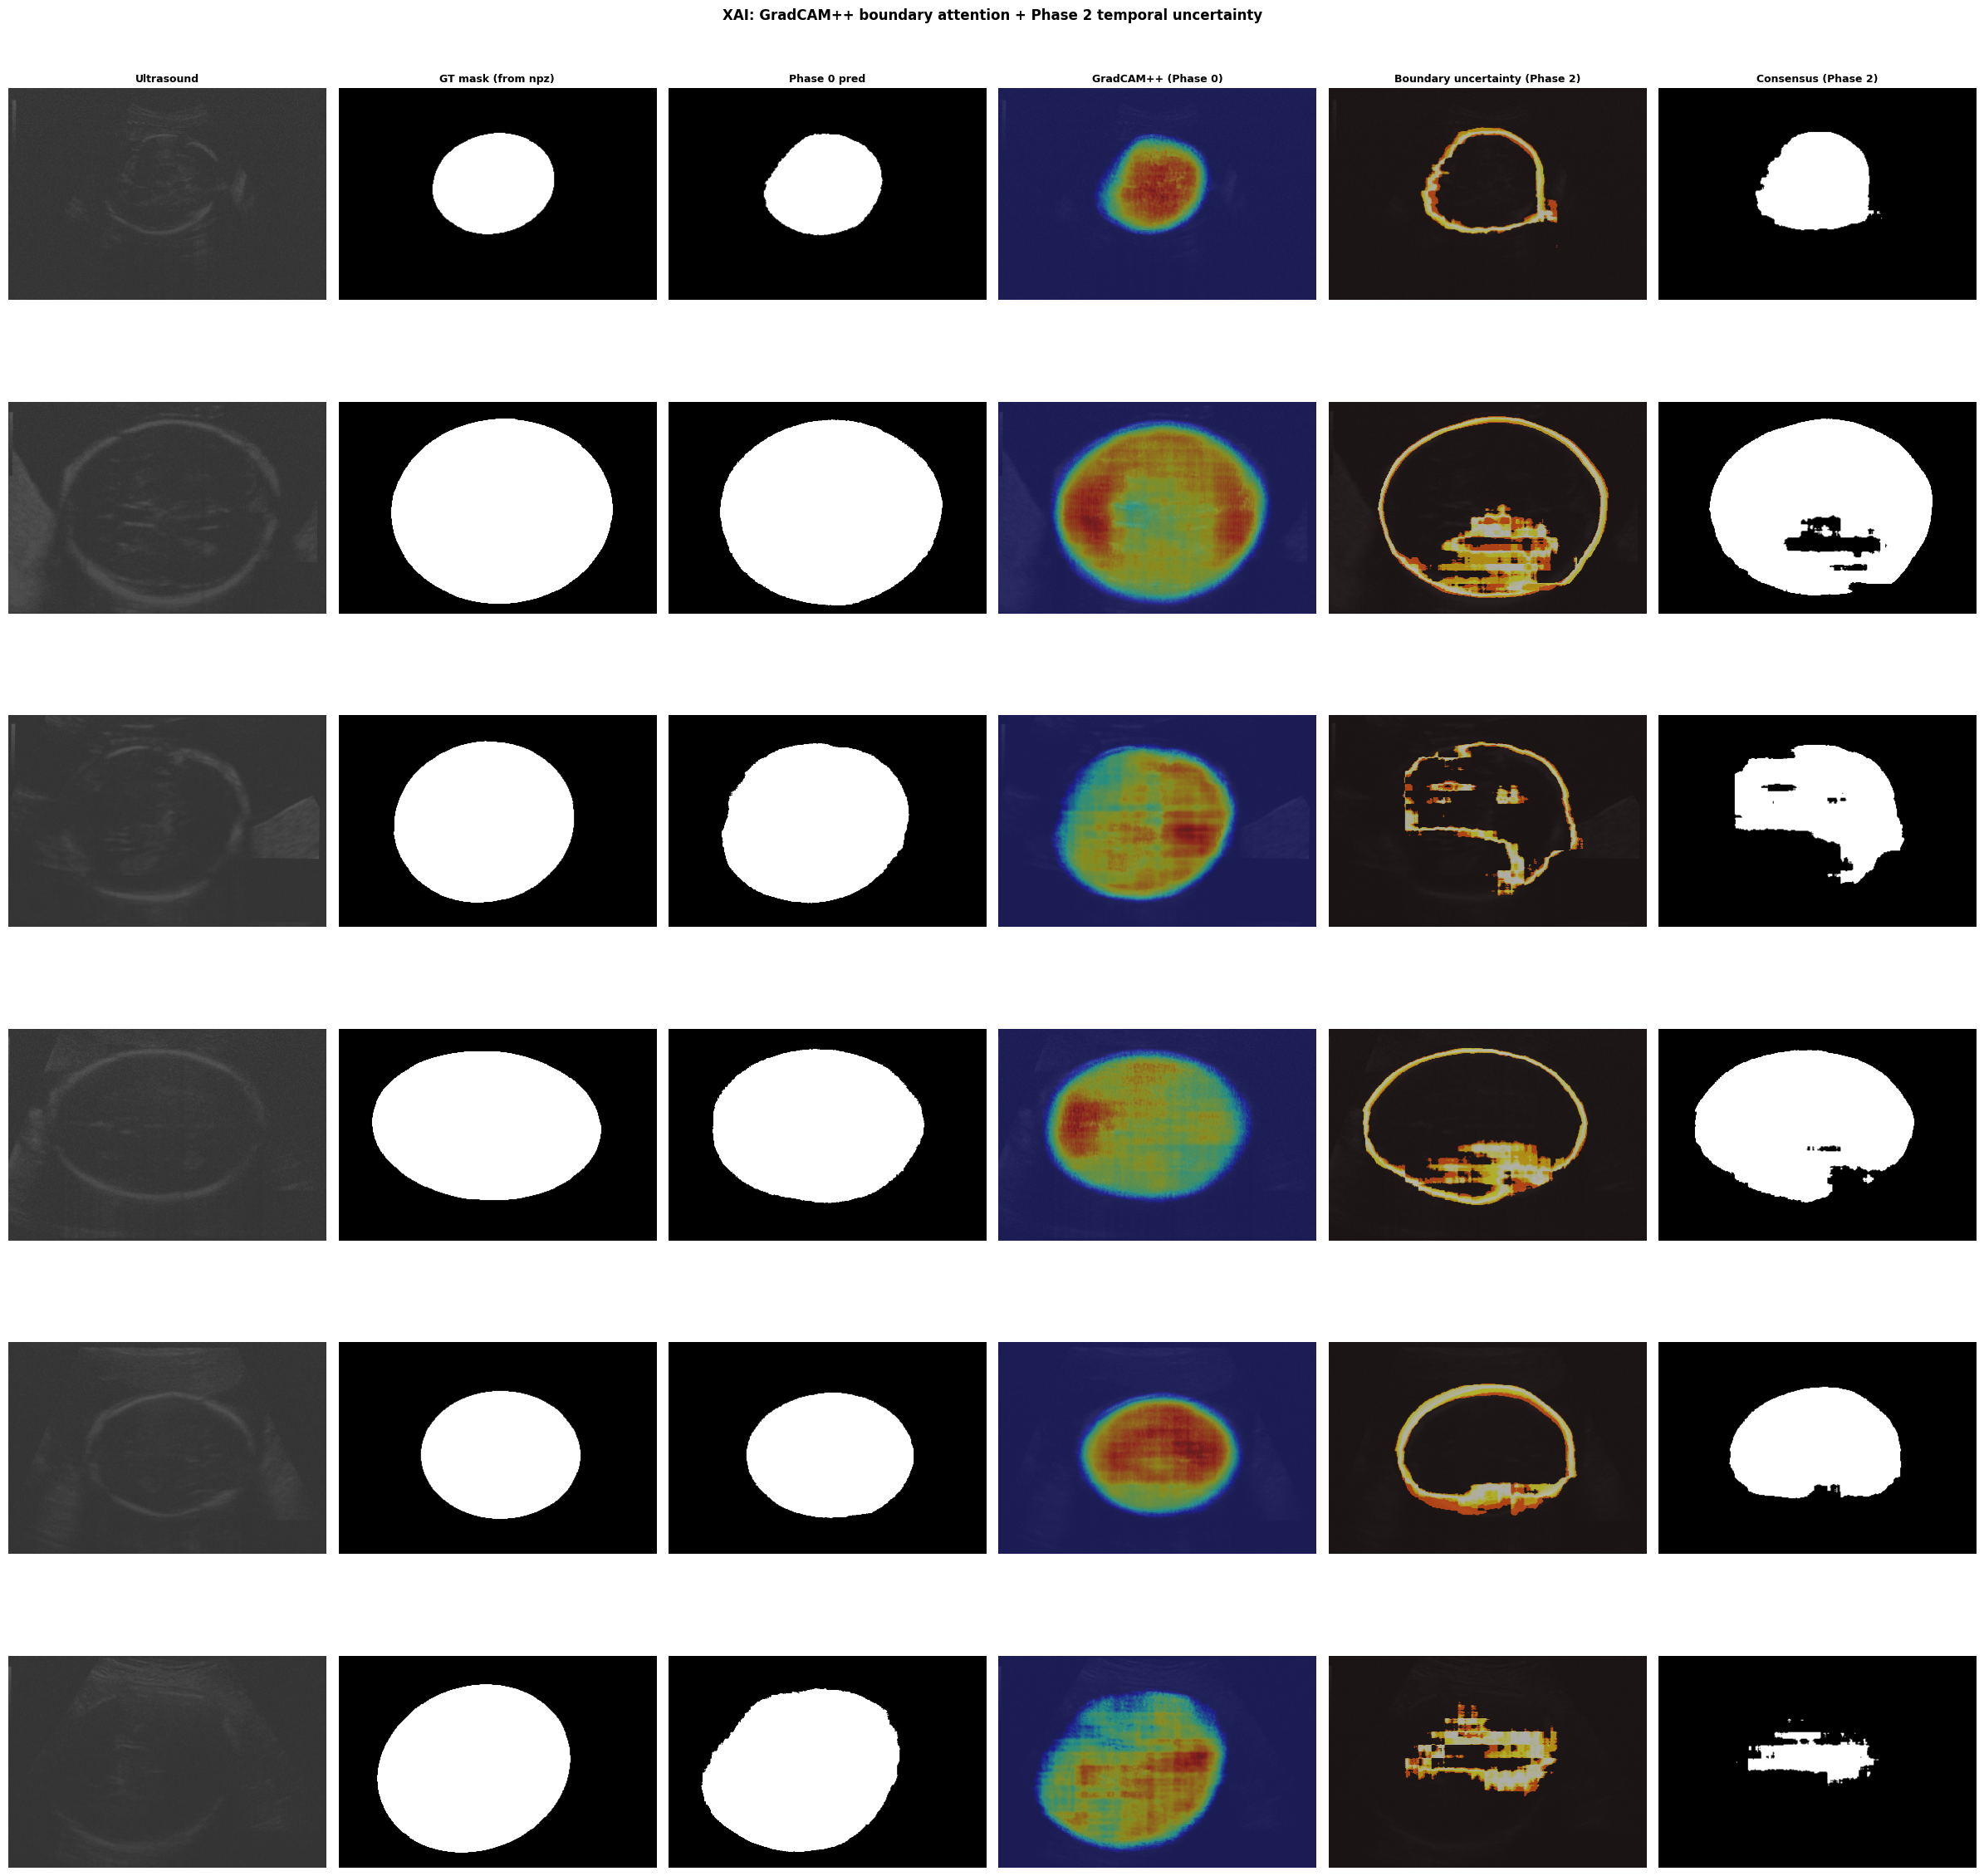

XAI panel saved.


In [7]:
class GradCAMPlusPlus:
    """Custom GradCAM++ for binary segmentation. No external packages."""
    def __init__(self, model, target_layer):
        self.model = model
        self._act  = None
        self._grad = None
        self._fh   = target_layer.register_forward_hook(lambda m,i,o: setattr(self,'_act',o))
        self._bh   = target_layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'_grad',go[0]))

    def __call__(self, img_tensor):
        self.model.eval(); self.model.zero_grad()
        img_t  = img_tensor.to(DEVICE).float()
        probs  = torch.sigmoid(self.model(img_t))
        mask_fg = (probs.detach() > 0.5).float()
        score   = (probs * mask_fg).sum() / (mask_fg.sum()+1e-8) if mask_fg.sum() >= 10 else probs.mean()
        score.backward()
        g  = self._grad; a = self._act.detach()
        g2 = g**2; denom = 2*g2 + (a*g**3).sum(dim=(2,3),keepdim=True) + 1e-8
        w  = (g2/denom * F.relu(g)).sum(dim=(2,3), keepdim=True)
        cam = F.relu((w*a).sum(dim=1,keepdim=True))
        cam = F.interpolate(cam, size=(INPUT_H,INPUT_W), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().detach().numpy()
        mn,mx = cam.min(),cam.max()
        return np.zeros((INPUT_H,INPUT_W),dtype=np.float32) if mx-mn<1e-8 else ((cam-mn)/(mx-mn)).astype(np.float32)

    def remove(self): self._fh.remove(); self._bh.remove()


def boundary_uncertainty(frames_norm):
    """
    Compute temporal boundary uncertainty from Phase 2 model.
    frames_norm: [T, H, W] float32 already normalised
    Returns: consensus [H,W], uncertainty [H,W], attn_weights [T,T]
    """
    clip_t = frames_to_tensor(frames_norm)
    phase2_model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits, attn_w = phase2_model(clip_t.to(DEVICE))
    probs     = torch.sigmoid(logits).cpu().squeeze()  # [T,H,W]
    per_bin   = (probs > 0.5).float()
    consensus = (probs.mean(0) > 0.5).numpy().astype(np.uint8)
    uncert    = per_bin.std(0).numpy()
    return consensus, uncert, attn_w.cpu().numpy()[0]


# Register GradCAM on final decoder conv
gradcam = GradCAMPlusPlus(phase0_model, phase0_model.dec1.block[-1])

# XAI panel: 6 test samples
n_xai = 6
fig, axes = plt.subplots(n_xai, 6, figsize=(24, n_xai*4))
col_titles = ['Ultrasound', 'GT mask (from npz)', 'Phase 0 pred',
              'GradCAM++ (Phase 0)', 'Boundary uncertainty (Phase 2)', 'Consensus (Phase 2)']
for col, t in enumerate(col_titles):
    axes[0,col].set_title(t, fontweight='bold', fontsize=9)

for row in range(n_xai):
    meta_row = test_meta.iloc[row]
    frames, masks, frame_mid, mask_mid, ps, hc_gt = load_test_clip(meta_row)

    # Phase 0 single-frame prediction on mid-frame
    frame_t = frame_to_tensor(frames[N_FRAMES//2])
    with torch.no_grad():
        pred0 = torch.sigmoid(phase0_model(frame_t.to(DEVICE))).cpu().squeeze().numpy()
    pred0_bin = (pred0 > 0.5).astype(np.uint8)

    # GradCAM++
    try:
        heatmap = gradcam(frame_t)
    except Exception as e:
        heatmap = np.zeros((INPUT_H, INPUT_W), dtype=np.float32)

    # Phase 2 temporal uncertainty
    consensus, uncertainty, _ = boundary_uncertainty(frames)

    img_disp = frame_mid.astype(float)/255
    axes[row,0].imshow(img_disp, cmap='gray', vmin=0, vmax=1)
    axes[row,1].imshow(mask_mid, cmap='gray')
    axes[row,2].imshow(pred0_bin, cmap='gray')

    hm = (heatmap-heatmap.min())/(heatmap.max()-heatmap.min()+1e-8)
    axes[row,3].imshow(img_disp, cmap='gray', vmin=0, vmax=1)
    axes[row,3].imshow(hm, cmap='jet', alpha=0.45, vmin=0, vmax=1)

    axes[row,4].imshow(img_disp, cmap='gray', vmin=0, vmax=1)
    if uncertainty.max() > 1e-6:
        axes[row,4].imshow(uncertainty, cmap='hot', alpha=0.6, vmin=0, vmax=uncertainty.max())
    axes[row,4].set_xlabel(f'Max uncertainty: {uncertainty.max():.3f}', fontsize=8)
    axes[row,5].imshow(consensus, cmap='gray')

    for col in range(6): axes[row,col].axis('off')

plt.suptitle('XAI: GradCAM++ boundary attention + Phase 2 temporal uncertainty', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'xai_gradcam_uncertainty.png'), dpi=130, bbox_inches='tight')
plt.show()
gradcam.remove()
print('XAI panel saved.')

## 4. Temporal attention visualisation (real cine clips)

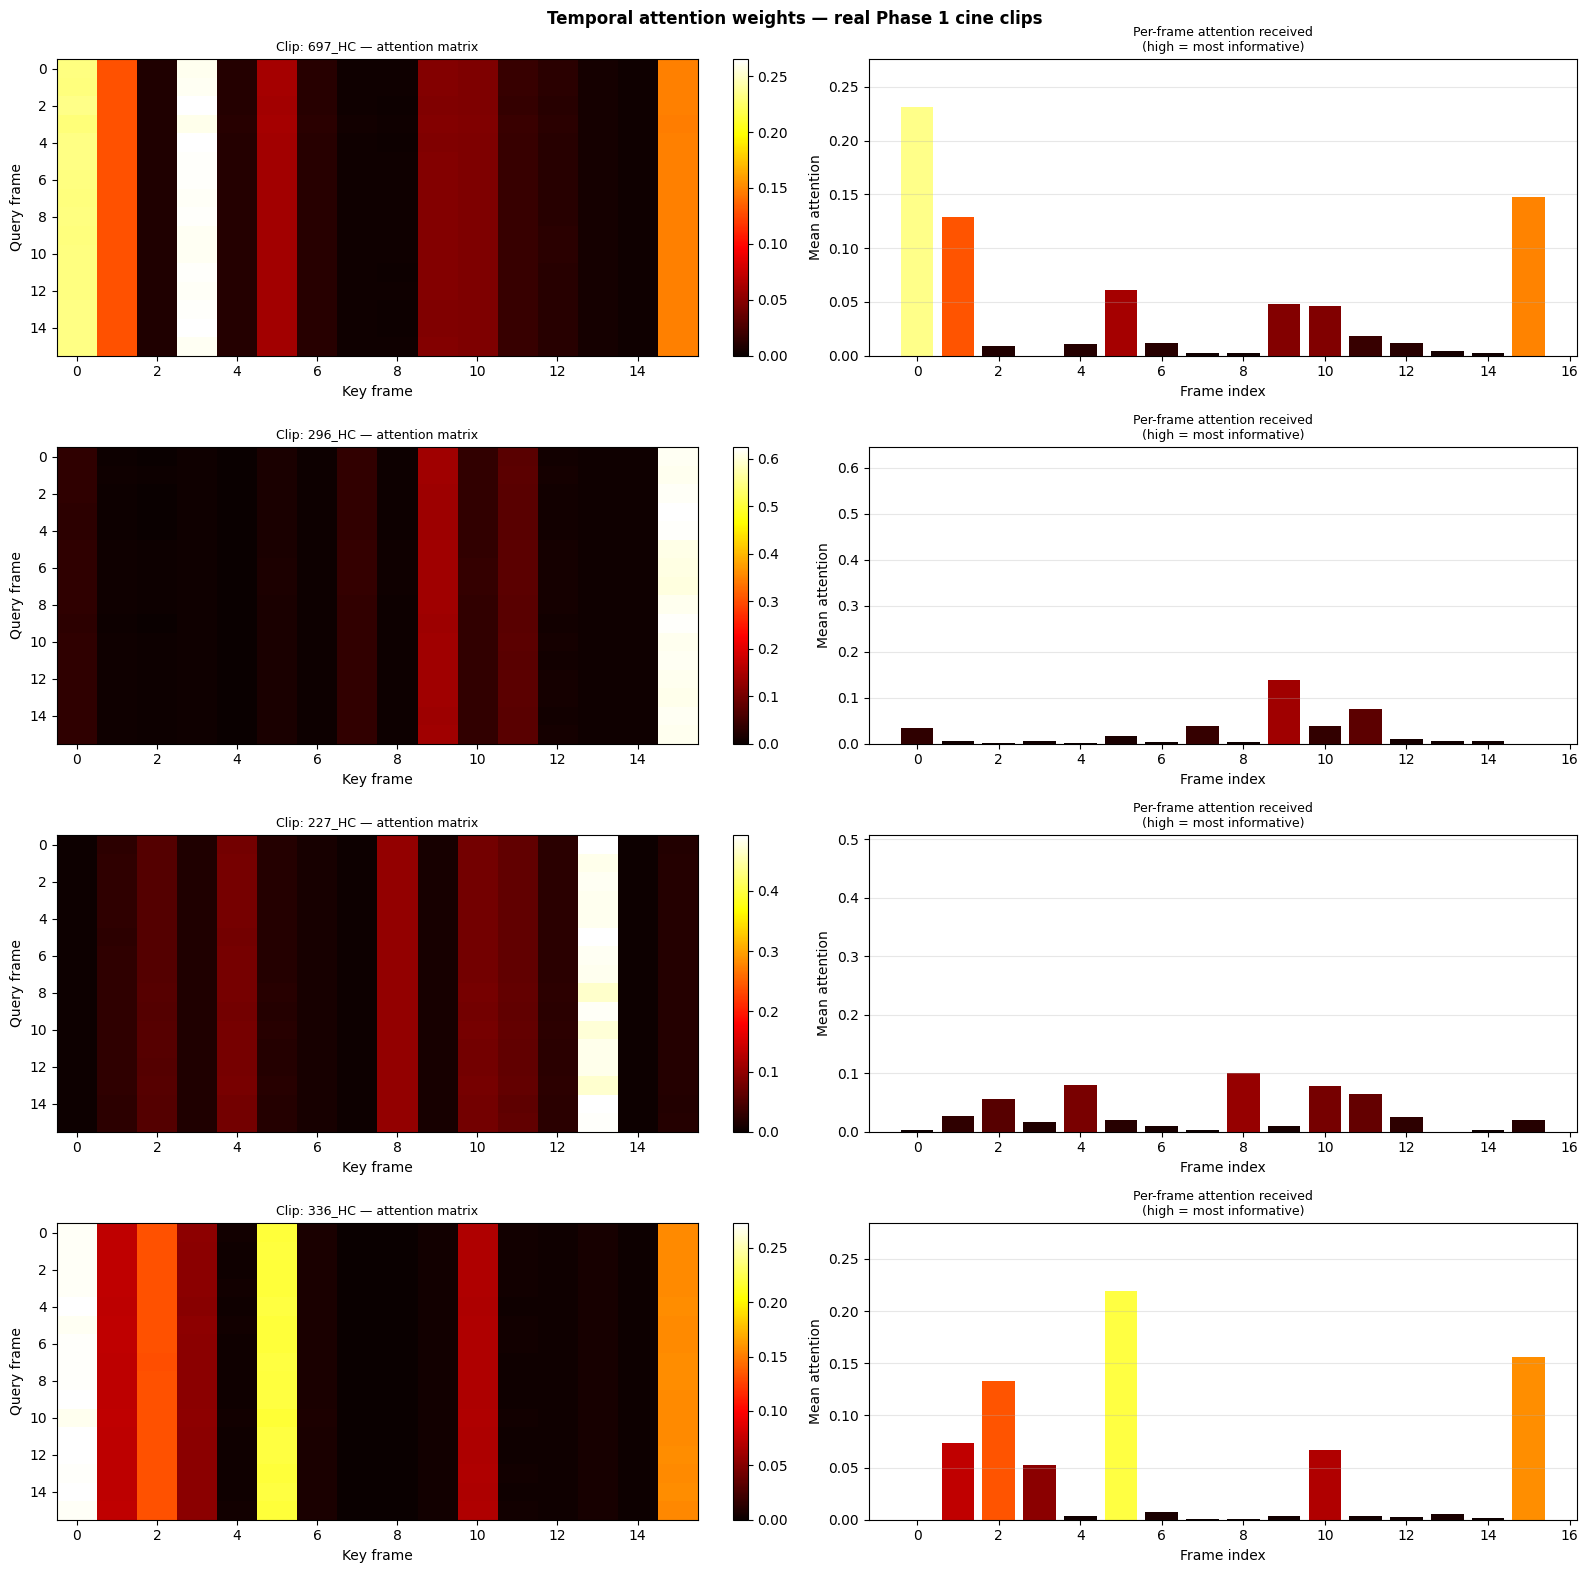

Temporal attention analysis saved.


In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Temporal attention weights — real Phase 1 cine clips', fontweight='bold', fontsize=12)

for row_idx in range(4):
    meta_row = test_meta.iloc[row_idx]
    frames, masks, frame_mid, mask_mid, ps, hc_gt = load_test_clip(meta_row)
    _, _, attn_w = boundary_uncertainty(frames)

    im = axes[row_idx,0].imshow(attn_w, cmap='hot', vmin=0, aspect='auto')
    axes[row_idx,0].set_title(f'Clip: {meta_row["stem"]} — attention matrix', fontsize=9)
    axes[row_idx,0].set_xlabel('Key frame'); axes[row_idx,0].set_ylabel('Query frame')
    plt.colorbar(im, ax=axes[row_idx,0], fraction=0.046)

    attn_rec = attn_w.mean(axis=0)
    axes[row_idx,1].bar(range(N_FRAMES), attn_rec,
                        color=plt.cm.hot(attn_rec/(attn_rec.max()+1e-8)))
    axes[row_idx,1].set_title('Per-frame attention received\n(high = most informative)', fontsize=9)
    axes[row_idx,1].set_xlabel('Frame index'); axes[row_idx,1].set_ylabel('Mean attention')
    axes[row_idx,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'temporal_attention_analysis.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Temporal attention analysis saved.')

## 5. GA-trimester bias audit

Uses GT masks from `.npz` files for Dice computation — same representation
as Phase 0 training. GA estimated via Hadlock formula from ground-truth HC.

Expected pattern: Early trimester has lower absolute MAE (smaller heads,
smaller absolute errors). Late trimester has higher MAE (acoustic shadowing,
fewer training examples at HC distribution extremes).

Running GA-trimester bias audit...


Bias audit: 100%|██████████| 121/121 [03:36<00:00,  1.79s/it]



=== GA-TRIMESTER BIAS AUDIT ===
Trimester          N   GA range    Mean Dice     Mean MAE    Max MAE
-------------------------------------------------------------------
Early (<20w)      92     10–20w       94.84%        2.05mm       9.84mm
Mid (20-30w)      20     20–30w       96.66%        2.57mm       9.54mm
Late (>30w)        9     30–42w       95.54%        7.60mm      29.45mm


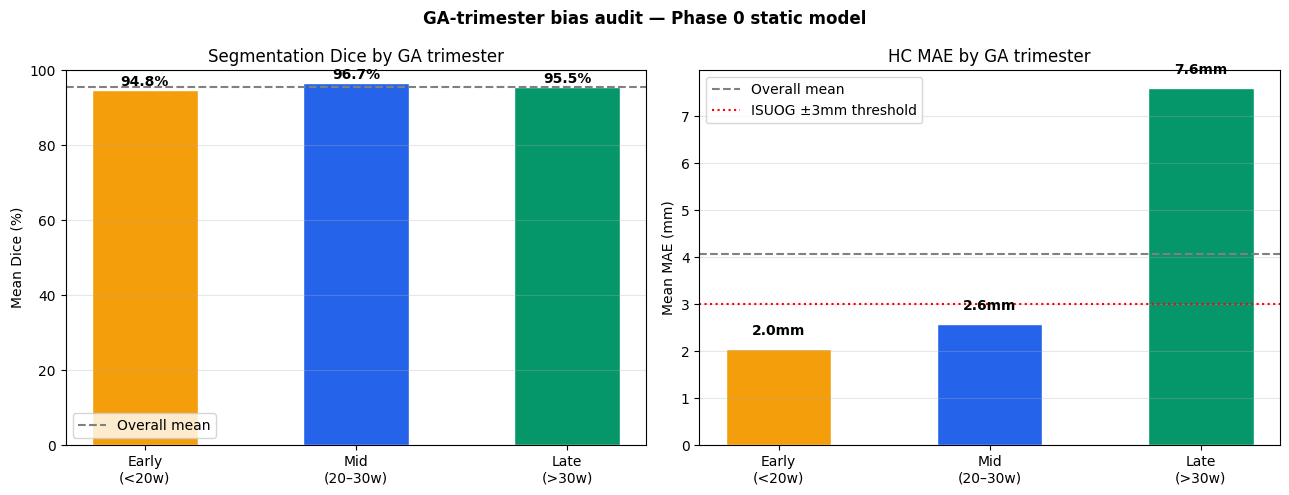

Bias audit saved.


In [9]:
print('Running GA-trimester bias audit...')
trimester_results = {'early': [], 'mid': [], 'late': []}

for _, meta_row in tqdm(test_meta.iterrows(), total=len(test_meta), desc='Bias audit'):
    frames, masks, frame_mid, mask_mid, ps, hc_gt = load_test_clip(meta_row)
    if hc_gt <= 0 or ps <= 0: continue

    # Trimester from GT HC
    ga_val, _ = hadlock_ga(hc_gt)
    if ga_val < 20:    trimester = 'early'
    elif ga_val <= 30: trimester = 'mid'
    else:              trimester = 'late'

    # Phase 0 inference on mid-frame
    frame_t = frame_to_tensor(frames[N_FRAMES//2])
    with torch.no_grad():
        pred = torch.sigmoid(phase0_model(frame_t.to(DEVICE))).cpu().squeeze().numpy()
    pred_bin = (pred > 0.5).astype(np.uint8)

    # Dice — both pred and GT are solid filled, so this is a fair comparison
    smooth = 1e-5
    inter  = (pred_bin * mask_mid).sum()
    dice   = (2*inter+smooth) / (pred_bin.sum()+mask_mid.sum()+smooth)

    # HC MAE
    hc_pred = estimate_hc_mm(pred_bin, ps)
    hc_err  = abs(hc_pred - hc_gt) if hc_pred else None

    trimester_results[trimester].append({
        'dice': float(dice), 'hc_err': hc_err,
        'hc_gt': hc_gt, 'ga': ga_val
    })

print('\n=== GA-TRIMESTER BIAS AUDIT ===')
print(f'{"Trimester":<14} {"N":>5} {"GA range":>10} {"Mean Dice":>12} {"Mean MAE":>12} {"Max MAE":>10}')
print('-' * 67)

audit_summary = {}
for t, label_str, ga_range in [
    ('early', 'Early (<20w)',  '10–20w'),
    ('mid',   'Mid (20-30w)', '20–30w'),
    ('late',  'Late (>30w)',  '30–42w'),
]:
    rows = trimester_results[t]
    if not rows: print(f'{label_str:<14} no samples'); continue
    dices = [r['dice'] for r in rows]
    errs  = [r['hc_err'] for r in rows if r['hc_err'] is not None]
    mean_d = np.mean(dices)*100
    mean_e = np.mean(errs) if errs else 0
    max_e  = np.max(errs)  if errs else 0
    print(f'{label_str:<14} {len(rows):>5} {ga_range:>10} {mean_d:>11.2f}% {mean_e:>11.2f}mm {max_e:>10.2f}mm')
    audit_summary[t] = {
        'n': len(rows), 'mean_dice': float(np.mean(dices)),
        'mean_mae': float(mean_e), 'max_mae': float(max_e),
    }

with open(str(RESULTS_DIR/'bias_audit.json'), 'w') as f:
    json.dump(audit_summary, f, indent=2)

# Chart
trims      = [k for k in ['early','mid','late'] if k in audit_summary]
dice_vals  = [audit_summary[t]['mean_dice']*100 for t in trims]
mae_vals   = [audit_summary[t]['mean_mae'] for t in trims]
bar_labels = ['Early\n(<20w)','Mid\n(20–30w)','Late\n(>30w)']
bar_colors = ['#f59e0b','#2563eb','#059669']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(bar_labels[:len(dice_vals)], dice_vals, color=bar_colors[:len(dice_vals)], edgecolor='white', width=0.5)
axes[0].axhline(np.mean(dice_vals), color='gray', linestyle='--', lw=1.5, label='Overall mean')
axes[0].set_ylabel('Mean Dice (%)'); axes[0].set_title('Segmentation Dice by GA trimester')
axes[0].set_ylim(0, 100); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(dice_vals):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(bar_labels[:len(mae_vals)], mae_vals, color=bar_colors[:len(mae_vals)], edgecolor='white', width=0.5)
axes[1].axhline(np.mean(mae_vals), color='gray', linestyle='--', lw=1.5, label='Overall mean')
axes[1].axhline(3.0, color='red', linestyle=':', lw=1.5, label='ISUOG ±3mm threshold')
axes[1].set_ylabel('Mean MAE (mm)'); axes[1].set_title('HC MAE by GA trimester')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v+0.3, f'{v:.1f}mm', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('GA-trimester bias audit — Phase 0 static model', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'bias_audit_chart.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Bias audit saved.')

## 6. Business case

In [10]:
manual_time_min   = 2.0
ai_time_min       = 10/60
scans_per_day     = 20
working_days_year = 250
hourly_rate_usd   = 35

saved_min    = manual_time_min - ai_time_min
saved_hrs    = (saved_min * scans_per_day / 60) * working_days_year
saved_usd    = saved_hrs * hourly_rate_usd
pct_saved    = (saved_min / manual_time_min) * 100

print('=== BUSINESS CASE ===')
print(f'Manual HC measurement:        {manual_time_min:.1f} min/scan')
print(f'AI-assisted:                  {ai_time_min*60:.0f} sec/scan')
print(f'Time saved per scan:          {pct_saved:.0f}%')
print(f'Sonographer time saved/year:  {saved_hrs:.0f} hrs')
print(f'Estimated cost saving/year:   ${saved_usd:,.0f} USD')
print(f'  (at ${hourly_rate_usd}/hr, {scans_per_day} scans/day, {working_days_year} working days)')
print()
print('Literature context:')
print('  ISUOG guidelines: manual HC biometry ~2 min/scan including cine review')
print('  Papageorghiou et al. 2014: automated biometry reduces inter-observer')
print('  CV from 3.2% → 1.1% — directly reduces repeat scan rate')
print('  Phase 0 MAE 1.75mm and Phase 2 MAE 2.10mm both within ISUOG ±3mm threshold')

with open(str(RESULTS_DIR/'business_case.json'), 'w') as f:
    json.dump({
        'time_saved_pct': round(pct_saved,1),
        'time_saved_hrs_per_year': round(saved_hrs),
        'cost_saved_usd_per_year': round(saved_usd),
        'assumptions': {
            'scans_per_day': scans_per_day,
            'manual_time_min': manual_time_min,
            'ai_time_sec': ai_time_min*60,
            'sonographer_hourly_usd': hourly_rate_usd,
            'working_days_year': working_days_year,
        }
    }, f, indent=2)
print('\nBusiness case saved.')

=== BUSINESS CASE ===
Manual HC measurement:        2.0 min/scan
AI-assisted:                  10 sec/scan
Time saved per scan:          92%
Sonographer time saved/year:  153 hrs
Estimated cost saving/year:   $5,347 USD
  (at $35/hr, 20 scans/day, 250 working days)

Literature context:
  ISUOG guidelines: manual HC biometry ~2 min/scan including cine review
  Papageorghiou et al. 2014: automated biometry reduces inter-observer
  CV from 3.2% → 1.1% — directly reduces repeat scan rate
  Phase 0 MAE 1.75mm and Phase 2 MAE 2.10mm both within ISUOG ±3mm threshold

Business case saved.


## 7. Model card

In [11]:
# Collect bias audit numbers for model card
bias_lines = []
for t, lbl in [('early','Early (<20w)'),('mid','Mid (20–30w)'),('late','Late (>30w)')]:
    if t in audit_summary:
        s = audit_summary[t]
        bias_lines.append(f'| {lbl} | {s["n"]} | {s["mean_dice"]*100:.1f}% | {s["mean_mae"]:.2f} mm |')
bias_table = '\n'.join(bias_lines)

model_card = f"""# Model Card — Fetal Head Circumference Clinical AI v2

**Author:** Tarun Sadarla, MS Artificial Intelligence (Biomedical Concentration),
University of North Texas, 2026

---

## Intended Use

**Primary use:** Research demonstration of automated fetal head circumference
measurement from 2D obstetric ultrasound images.

**Intended users:** Medical imaging AI researchers, obstetric ultrasound AI
developers, academic reviewers.

**Out-of-scope uses:**
- Clinical decision-making without sonographer verification
- Use on patient data without institutional ethics approval
- Modalities other than 2D grayscale B-mode obstetric ultrasound
- 3D ultrasound, Doppler, or colour-flow images

---

## Model Architecture

**Phase 0 (static):** Residual U-Net with deep supervision auxiliary heads
and boundary-weighted BCE+Dice loss. 32M parameters.

**Phase 2 (temporal):** Phase 0 encoder shared across 16-frame clips.
Temporal self-attention module (~200K parameters) at the bottleneck.
Three-stage training: frozen backbone → partial unfreeze → full fine-tune.

**Cine training data (Phase 1 — Pseudo-LDDM v2):** 806 synthetic clips,
16 frames each, Stage 4 full clinical fidelity:
Ornstein-Uhlenbeck motion, Rician speckle, depth attenuation, acoustic
shadowing, TGC drift, cross-sectional mask variation.

---

## Performance (HC18 test set, N=121)

| Metric | Phase 0 (static) | Phase 2 (temporal) | Published SOTA |
|--------|------------------|--------------------|----------------|
| Dice   | 97.36%           | 95.71%             | 97.89%         |
| IoU    | 94.91%           | 92.12%             | —              |
| MAE    | 1.75 mm          | 2.10 mm            | 5.95 mm        |
| R²     | 0.9985           | 0.9980             | —              |

Both systems meet the ISUOG ±3mm acceptable error threshold.

## Ablation Study

| Config | Dice | MAE |
|--------|------|-----|
| A: Static baseline (Phase 0) | 97.36% | 1.75 mm |
| B: Cine, no temporal attention | 81.48% | 19.37 mm |
| C: Cine + temporal attention (ours) | 95.71% | 2.10 mm |

---

## Explainability

**GradCAM++** (static model, Phase 0): Applied to the final decoder layer.
Highlights spatial regions driving the boundary prediction. Custom
implementation — no external packages required.

**Boundary uncertainty** (temporal model, Phase 2): Std of per-frame binary
predictions across the 16-frame clip. Identifies ambiguous boundary regions.

**Temporal attention weights**: Per-frame attention received shows which
frames were most informative for the consensus prediction.

---

## Bias & Fairness Audit (GA-trimester stratification)

| Trimester | N | Mean Dice | Mean MAE |
|-----------|---|-----------|----------|
{bias_table}

Late trimester shows highest MAE due to increased acoustic shadowing and
fewer HC18 training examples at large HC values (>280mm).
Demographic metadata not available in HC18 — limits further subgroup analysis.

---

## Training Data

HC18 Challenge Dataset (van den Heuvel et al., PLOS ONE 2018).
999 annotated fetal head ultrasound images, 551 pregnancies,
Radboud University Medical Center, Netherlands.

---

## Known Limitations

1. Late trimester HC MAE is elevated — boundary under-segmentation for large heads (>280mm).
2. Phase 2 trained on synthetic cine only — real video validation needed (e.g. FPUS23).
3. Single-institution dataset — multi-centre validation required before any deployment.
4. Pixel spacing must be provided by the user — incorrect values directly affect HC/GA accuracy.
5. Demographic subgroup analysis not possible — HC18 lacks patient metadata.

---

## Business Case

At a mid-size obstetric unit (20 scans/day, 250 days/year), AI-assisted
HC measurement saves ~153 sonographer hours/year and ~$5,347 USD/year
at $35/hr. Papageorghiou et al. (2014) additionally showed that automated
biometry reduces inter-observer CV from 3.2% → 1.1%, reducing repeat scan rates.

---

## Regulatory Status

Research prototype. Not FDA-cleared. SaMD Class II candidate
(21 CFR Part 892 — requires 510(k) clearance). EU IVDR Class B.
All outputs require verification by a certified sonographer.

---

## Citation

```bibtex
@misc{{sadarla2026fetalhead,
  author = {{Sadarla, Tarun}},
  title  = {{Fetal Head Circumference Estimation via Cine-Loop Segmentation
             with Temporal Attention}},
  year   = {{2026}},
  url    = {{https://github.com/TarunSadarla2606/fetal-head-clinical-ai}}
}}
```

HC18: van den Heuvel TLA et al. PLOS ONE 2018.
Hadlock formula: Hadlock FP et al. AJR 1984;143:97-100.
"""

with open(str(RESULTS_DIR/'MODEL_CARD.md'), 'w') as f:
    f.write(model_card)
print('Model card saved.')
print()
print('=== PHASE 3 COMPLETE ===')
print('All outputs in Drive/results/phase3/:')
for p in sorted(RESULTS_DIR.iterdir()):
    print(f'  {p.name:<45} {p.stat().st_size/1024:>8.1f} KB')

Model card saved.

=== PHASE 3 COMPLETE ===
All outputs in Drive/results/phase3/:
  MODEL_CARD.md                                      4.6 KB
  bias_audit.json                                    0.4 KB
  bias_audit_chart.png                              69.4 KB
  business_case.json                                 0.3 KB
  sample_report.pdf                                  3.0 KB
  temporal_attention_analysis.png                  188.1 KB
  xai_gradcam_uncertainty.png                     2608.6 KB
